# LLM을 위한 Tabular Data - Context Engineering

꼭 다시 한번 더 `uv sync --all-groups --frozen` 을 실행하셨는지 확인해주세요.  


> 1) **Table 데이터는 함축적인 데이터(LLM 이 Tabular 데이터를 잘 활용하지 못하는 근본적인 이유!)**
>    - 단순하게 테이블 데이터만 봐서는 도메인 지식이 없으면 해석이 불가능하거나 위험합니다.
>    - 올바른 해석을 위해서는 추가적인 **도메인 지식 주입** 또는 추가 처리(전처리/후처리)가 필요합니다.
>
> 2) **Tabular 데이터를 LLM 전송용 컨텍스트로 변환하려면**
>    - 운영 환경에서는 Tabular 데이터를 다루기 편리하도록 **CSV 등 구조화된 파일의 형태로 보관**하고,
>    - 문서/벡터 스토어에는 해당 CSV의 **링크와 메타데이터(연도, 회사, 단위, 통화 등)**만 등록해 두는 패턴이 가장 유용합니다.
>    - 일부 시스템은 모든 행과 열을 자연어 문장으로 직렬화해서 순수 텍스트로만 보관하기도 합니다.

## TAG(Table Augmented Generation) 이랑 착각하시면 안됩니다.
[Text2SQL is Not Enough: Unifying AI and Databases with TAG](https://arxiv.org/abs/2408.14717)
- TAG 는 Text2SQL 을 조금 더 유기적으로 활용하는 데 중점을 둔 접근입니다.
- **본 실습에서 다루는 Tabular 데이터는 `DB에 넣기 어려운 문서 내부의 작은 테이블들`을 어떻게 추출하고 처리한 뒤 직렬화해서 LLM 의 Input Context로 쓸지에 초점.**
> 핵심: LLM 이 이해 가능하도록 **직렬화** (CSV 로 서술, 자연어 서술, 스키마+요약)

---

## 테이블 데이터 컨텍스트 엔지니어링

1. **테이블 의미론**: 스키마, 제약조건, 관계 등 테이블이 암묵적으로 담고 있는 정보를 이해한다.
2. **직렬화 트레이드오프**: CSV / Pandas / 자연어 / 스키마+요약 사이의 장단점을 비교한다.
3. **도메인 지식 주입**: 테이블이 혼자 있으면 빠져 있는 "회사, 연도, 단위, 통화" 같은 정보를 어떻게 채워 넣을지 배운다.
4. **통계적 강화**: 최소/최대/평균/추세 등 요약 통계를 추가해 LLM이 계산을 직접하지 않도록 하고, Tool 을 사용하며, 결과를 활용한 인사이트를 더 잘 내도록 만든다.


## 테이블 데이터가 유독 LLM 에게 어려운 이유

**예시 테이블**

| Q | Revenue |
|---|---------|
| Q1 | 314 |
| Q2 | 323.4 |
| Q3 | 340.2 |

표만 보면 다음 정보가 전혀 없다.

- 어느 회사의 매출인지?
- 몇 년도의 데이터인지?
- 단위가 무엇인지? (백만? 천? 원? 달러?)
- 통화 단위는 무엇인지?

> 인사이트: 테이블은 최대한 압축된 표현이다. 사람 독자는 도메인 지식으로 빈칸을 채우지만, LLM 은 그렇지 못하다.

```python
# 사용자 질문: "Q2 매출 성장률은?"
# 검색 결과: "323.4"
# LLM 환각: "매출이 323.4로 성장했습니다"  # 단위/맥락 누락
```

그래서 **명시적 컨텍스트 주입**이 필수.


## 도메인 지식 / 비즈니스 규칙 주입 패턴

테이블만 던지는 대신, 다음과 같은 구조화된 컨텍스트를 함께 넣을 수 있다.

- **스키마 인식 직렬화**
  - 예: `Quarter`는 "회계 분기(Q1–Q4)", `Revenue`는 "백만 달러 단위 총 매출".
  - LLM 이 컬럼 의미를 오해하지 않도록 미리 정의한다.

- **관계 컨텍스트**
  - 어떤 컬럼이 다른 테이블의 키를 참조하는지, 연관된 테이블은 무엇인지 명시한다.
  - 예: `product_id` → `products.id` 참조, `related_tables`: `["expenses", "forecasts"]`.

- **비즈니스 규칙**
  - 매출 계산 방식, 계절성, 비교 규칙 등을 자연어로 적어 둔다.
  - 예: "매출 = sum(sales) - returns", "연휴 시즌인 Q4는 평소보다 매출이 높다".

이런 패턴을 써서 "숫자만 있는 테이블"을 "맥락이 풍부한 지식 그래프의 한 조각"처럼 느껴지게 만드는 것이 목표다.


## 언제 / 어떤 직렬화를 쓸까?

**사용 사례별 전략**

| 사용 사례 | 추천 방법 | 이유 |
|----------|-----------|------|
| 단순 QA ("Q2 매출은?") | 행별 자연어 서술 | 자연어로 바로 답변 가능 |
| 복잡한 계산 ("성장률은?") | 스키마 + CSV 링크 | 에이전트가 CSV 를 로드해 직접 계산 |
| 대형 테이블 (100+ 행) | 스키마 + 요약만 | 토큰 효율성, 전체 테이블 임베딩 불필요 |
| 실시간/자주 변하는 데이터 | CSV / DB 링크 | 오래된 스냅샷을 LLM 에 심어두지 않는다 |

**적용을 고민해야 할 것**

- 메타데이터 포함: 문서, 테이블 이름, 연도, 단위, 통화.
- 컬럼 타입과 값 범위(최소/최대/평균 등) 제공.
- 전체 테이블 대신 통계 요약 + CSV/DB 경로 제공.
- 도메인별 용어를 일관되게 사용.

**피해야 할 것**

- 원본 CSV 텍스트를 아무 의미없이 기계적으로 임베딩해 토큰을 낭비하는 것.
- 단위/통화를 생략해버리고 "숫자"만 남기는 것.
- LLM 이 비즈니스 규칙을 이미 안다고 가정하는 것.
- 외래키/테이블 관계를 무시한 채 테이블 하나만 떼어내어 저장하는 것.

**Tabular data 의 Context-Engineering 을 더 공부해보고 싶으시다면**

- [RAG를 위한 Table-to-Text 방법](https://arxiv.org/html/2402.12869v2)
- [Awesome-LLM-Tabular](https://github.com/johnnyhwu/Awesome-LLM-Tabular)
- [Three Paths to Table Understanding with LLMs](https://medium.com/@kate.ruksha/three-paths-to-table-understanding-with-llms-dc0648be4192)


In [ ]:
# Setup
import sys
from pathlib import Path

import nest_asyncio
import pandas as pd
from dotenv import find_dotenv, load_dotenv
from IPython.display import display
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI

from openrouter_llm import create_openrouter_llm


sys.path.append(str(Path.cwd().parent))

# .env 파일 자동 탐색 및 로드
dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path, verbose=True)
else:
    print("⚠️  .env 파일을 찾지 못했습니다.")

nest_asyncio.apply()

llm = ChatOpenAI(model="gpt-4.1", temperature=0.0)
# llm = create_openrouter_llm(model="gpt-4.1", temperature=0.0)

## Document 기반 Parsing 된 데이터 속에 있는 Tabular Data

In [50]:
# 실습용 예시 시나리오: 문서 안에 포함된 작은 테이블들 (Markdown / HTML)

# 1) 내부 재무 보고서 본문 (Markdown 테이블)
financial_report_content_md = """
ACME 기업 2025년 분기별 매출 요약 보고서 (내부용)

아래 표는 2025년 한 해 동안의 분기별 매출 요약입니다.

| 연도 | 분기 | 매출_백만달러 |
|------|------|---------------|
| 2025 | Q1   | 380.2         |
| 2025 | Q2   | 392.4         |
| 2025 | Q3   | 405.7         |
| 2025 | Q4   | 418.9         |

또한 Q4 매출은 아래와 같이 제품 라인별로 구성됩니다.

| 분기 | 제품라인            | 매출_백만달러 |
|------|---------------------|---------------|
| Q4   | 클라우드 구독       | 245.3         |
| Q4   | 온프레미스 라이선스 | 102.7         |
| Q4   | 컨설팅 서비스       | 70.9          |
"""

financial_report_doc_md = Document(
    page_content=financial_report_content_md,
    metadata={
        "source": "internal_finance_report_markdown",
        "company": "ACME",
        "year": 2025,
        "doc_type": "quarterly_summary",
        "tables": [
            {
                "table_id": "acme_2025_quarterly_revenue",
                "description": "2025년 분기별 총 매출 요약",
                "format": "markdown",
            },
            {
                "table_id": "acme_2025_q4_segment_revenue",
                "description": "2025년 Q4 제품 라인별 매출",
                "format": "markdown",
            },
        ],
    },
)

# 2) 같은 내용을 담은 웹 대시보드 HTML 조각 (스크래핑된 페이지를 가정)
financial_report_content_html = """
<div class="report">
  <h2>ACME 2025 Quarterly Revenue (Internal)</h2>
  <p>The following table summarizes total revenue by quarter in 2025.</p>
  <table id="tbl-quarterly-revenue">
    <thead>
      <tr><th>Year</th><th>Quarter</th><th>Revenue_Million_USD</th></tr>
    </thead>
    <tbody>
      <tr><td>2025</td><td>Q1</td><td>380.2</td></tr>
      <tr><td>2025</td><td>Q2</td><td>392.4</td></tr>
      <tr><td>2025</td><td>Q3</td><td>405.7</td></tr>
      <tr><td>2025</td><td>Q4</td><td>418.9</td></tr>
    </tbody>
  </table>
</div>
"""

financial_report_doc_html = Document(
    page_content=financial_report_content_html,
    metadata={
        "source": "internal_finance_dashboard_html",
        "company": "ACME",
        "year": 2025,
        "doc_type": "quarterly_summary",
        "tables": [
            {
                "table_id": "acme_2025_quarterly_revenue_html",
                "description": "웹 대시보드에서 스크래핑된 2025년 분기별 매출",
                "format": "html",
                "dom_id": "tbl-quarterly-revenue",
            }
        ],
    },
)

# 실습용으로, 위 문서에서 이미 파싱된 첫 번째 분기별 매출 테이블이라고 가정

df = pd.DataFrame(
    {
        "Year": [2025, 2025, 2025, 2025],
        "Quarter": ["Q1", "Q2", "Q3", "Q4"],
        "Revenue": [380.2, 392.4, 405.7, 418.9],
    }
)

metadata = {
    "title": "ACME 기업 2025년 분기별 매출 보고서",
    "year": 2025,
    "company": "ACME",
    "table_name": "분기별 매출",
    "table_id": "acme_2025_quarterly_revenue",
    "unit": "백만 달러",
    "currency": "USD",
}

## 간단한 문자열 표현

In [ ]:
# 물론 Markdown Table 그대로 사용할 수도 있습니다.


def method1_pandas_string(df: pd.DataFrame, metadata: dict) -> str:
    """방법 1: 제일 간단하게 Pandas 문자열로 표현."""
    header_lines = [
        f"문서: {metadata.get('title')}",
        f"회사: {metadata.get('company')}",
        f"연도: {metadata.get('year')}",
        f"테이블: {metadata.get('table_name')} ({metadata.get('unit')})",
        "",
    ]
    body = df.to_string(index=False)
    return "\n".join(header_lines) + "\n" + body


# 테스트
result1 = method1_pandas_string(df, metadata)
result1

'문서: ACME 기업 2025년 분기별 매출 보고서\n회사: ACME\n연도: 2025\n테이블: 분기별 매출 (백만 달러)\n\n Year Quarter  Revenue\n 2025      Q1    380.2\n 2025      Q2    392.4\n 2025      Q3    405.7\n 2025      Q4    418.9'

## 직렬화 방법: 자연어 서술

In [51]:
def method2_narrative(df: pd.DataFrame, metadata: dict) -> str:
    """방법 2: 행별 자연어 서술."""
    # - 행을 반복하면서, 자연스러운 문장 생성 (예: "2023년 Q1에, 매출은 314 백만 달러")
    # - 각 컬럼 의미를 절대로 누락시키면 안됌
    title = metadata.get("title", "")
    year = metadata.get("year", "")
    company = metadata.get("company", "")
    unit = metadata.get("unit", "")

    lines: list[str] = [f"{title} ({year}) - {company}", ""]

    for _, row in df.iterrows():
        row_year = row.get("Year", year)
        quarter = row["Quarter"]
        revenue = row["Revenue"]
        sentence = f"{row_year}년 {quarter}에, 매출은 {revenue} {unit}"
        lines.append(sentence)

    return "\n".join(lines)


# 테스트
result2 = method2_narrative(df, metadata)
result2

'ACME 기업 2025년 분기별 매출 보고서 (2025) - ACME\n\n2025년 Q1에, 매출은 380.2 백만 달러\n2025년 Q2에, 매출은 392.4 백만 달러\n2025년 Q3에, 매출은 405.7 백만 달러\n2025년 Q4에, 매출은 418.9 백만 달러'

## 직렬화 방법: 스키마 + 요약 + CSV 링크

In [52]:
def method3_schema_summary(df: pd.DataFrame, metadata: dict) -> str:
    """방법 3: 통계가 포함된 스키마 + 요약 + CSV 링크."""
    # 1. 메타데이터 섹션
    # 2. 스키마 섹션 (컬럼명, 타입, 숫자의 경우 최소/최대/평균)
    # 3. 요약 섹션 (추세, 주요 인사이트)
    # 4. CSV 링크 (예: "/workspace/tables/{table_id}.csv")
    context = f"문서: {metadata.get('title')} ({metadata.get('year')})\n"
    context += f"회사: {metadata.get('company')}\n"
    context += f"테이블: {metadata.get('table_name')}\n\n"

    # 스키마 섹션
    context += "스키마:\n"
    for col in df.columns:
        dtype = df[col].dtype
        if dtype in ["int64", "float64"]:
            context += (
                f"- {col} ({dtype}): 최소={df[col].min()}, "
                f"최대={df[col].max()}, 평균={df[col].mean():.1f}\n"
            )
        else:
            context += f"- {col} ({dtype})\n"

    # CSV 링크 섹션
    table_id = metadata.get("table_id")
    context += f"\n데이터 위치: /workspace/tables/{table_id}.csv\n"
    context += "NOTE: 복잡한 쿼리 처리를 위해 pandas로 데이터를 로드하세요.\n\n"

    # 요약 섹션
    unit = metadata.get("unit", "")
    context += "요약:\n"
    context += f"- 총 행 수: {len(df)}\n"
    context += (
        f"- 매출 추세: {df['Revenue'].iloc[0]:.1f} → "
        f"{df['Revenue'].iloc[-1]:.1f} {unit}\n"
    )

    return context


# 테스트
result3 = method3_schema_summary(df, metadata)
print(result3)

문서: ACME 기업 2025년 분기별 매출 보고서 (2025)
회사: ACME
테이블: 분기별 매출

스키마:
- Year (int64): 최소=2025, 최대=2025, 평균=2025.0
- Quarter (object)
- Revenue (float64): 최소=380.2, 최대=418.9, 평균=399.3

데이터 위치: /workspace/tables/acme_2025_quarterly_revenue.csv
NOTE: 복잡한 쿼리 처리를 위해 pandas로 데이터를 로드하세요.

요약:
- 총 행 수: 4
- 매출 추세: 380.2 → 418.9 백만 달러



---
---

## PDF 테이블 추출 실습

이제 실제 PDF 문서에서 테이블을 추출하고, 위에서 배운 직렬화 방법들을 적용해봅니다.

### 학습 목표
1. Upstage Document Parser로 PDF에서 테이블 추출
2. 추출된 HTML/Markdown에서 DataFrame 변환
3. 직렬화 방법 비교
4. Multi-modal LLM으로 파싱 정확도 검증

In [54]:
# Part B: PDF 테이블 추출 - 환경 설정
import os
from pathlib import Path

from dotenv import load_dotenv

# tabular_utils 모듈 임포트
from tabular_utils import (
    TableMetadata,
    TokenCounter,
    compare_serialization_methods,
    extract_tables_from_html,
    extract_tables_from_markdown,
    get_recommended_serialization,
    pdf_to_images,
    save_tables_to_csv,
    serialize_compressed_json,
    serialize_narrative,
    serialize_pandas_string,
    serialize_query_adaptive,
    serialize_schema_summary,
    serialize_selective_stats,
    verify_table_with_vision_sync,
)
from upstage_parse import UpstageDocumentParser


load_dotenv()

# 환경 변수 확인
assert os.getenv("UPSTAGE_API_KEY"), "UPSTAGE_API_KEY가 설정되지 않았습니다"
# assert os.getenv("OPENROUTER_API_KEY"), "OPENROUTER_API_KEY가 설정되지 않았습니다"

print("✅ 환경 설정 완료")
print(f"   - UPSTAGE_API_KEY: {'설정됨' if os.getenv('UPSTAGE_API_KEY') else '미설정'}")
# print(
#     f"   - OPENROUTER_API_KEY: {'설정됨' if os.getenv('OPENROUTER_API_KEY') else '미설정'}"
# )

✅ 환경 설정 완료
   - UPSTAGE_API_KEY: 설정됨


### Step 1: PDF 파싱 (Upstage Document Parser)

`data/chapter02_table_data.pdf`를 파싱합니다.  
이 문서는 SK증권의 2026년 IT장비/소재 전망 보고서입니다.

**Upstage Parser 주요 옵션:**
- `chart_recognition=True`: 차트를 테이블로 변환
- `merge_multipage_tables=True`: 페이지를 넘어가는 테이블 병합
- `ocr="auto"`: 필요시 자동 OCR 적용

In [ ]:
# PDF 파싱 (캐싱 지원)
PDF_PATH = Path("data/chapter02_table_data.pdf")
PARSED_DIR = Path("data/parsed")
TABLES_DIR = Path("data/tables")

# 캐시 파일 경로
cache_html = PARSED_DIR / "chapter02_table_data.html"
cache_md = PARSED_DIR / "chapter02_table_data.md"
cache_meta = PARSED_DIR / "chapter02_table_data_metadata.json"

# 캐시가 있으면 로드, 없으면 파싱
if cache_html.exists() and cache_md.exists():
    print("📂 캐시된 파싱 결과 로드 중...")
    html_content = cache_html.read_text(encoding="utf-8")
    md_content = cache_md.read_text(encoding="utf-8")
    print(f"   - HTML: {len(html_content):,} 문자")
    print(f"   - Markdown: {len(md_content):,} 문자")
else:
    print("🔄 PDF 파싱 중 (Upstage Document Parser)...")
    parser = UpstageDocumentParser()
    result = parser.parse_document(
        str(PDF_PATH),
        chart_recognition=True,
        merge_multipage_tables=True,
        ocr="auto",
    )

    # 결과 저장
    html_content = result.html or ""
    md_content = result.markdown or ""

    parser.save_parse_result(
        result, str(PARSED_DIR), base_filename="chapter02_table_data"
    )

    print("✅ 파싱 완료")
    print(f"   - HTML: {len(html_content):,} 문자")
    print(f"   - Markdown: {len(md_content):,} 문자")
    print(f"   - 저장 위치: {PARSED_DIR}")

📂 캐시된 파싱 결과 로드 중...
   - HTML: 195,465 문자
   - Markdown: 120,197 문자


### Step 2: 테이블 추출

HTML에서 `<table>` 태그를 찾아 DataFrame으로 변환합니다.

In [56]:
# HTML에서 테이블 추출
tables = extract_tables_from_html(html_content)

print(f"📊 추출된 테이블 수: {len(tables)}\n")

for i, table in enumerate(tables):
    if "dataframe" in table:
        df_table = table["dataframe"]
        print(f"테이블 {i}: {table['table_id']}")
        print(f"   - 행: {table['row_count']}, 열: {table['col_count']}")
        print(f"   - 컬럼: {list(df_table.columns)[:5]}...")  # 처음 5개만
        if table.get("context"):
            ctx = table["context"]
            if "caption" in ctx:
                print(f"   - 캡션: {ctx['caption'][:50]}...")
        print()
    else:
        print(
            f"테이블 {i}: {table['table_id']} - 파싱 실패: {table.get('error', 'Unknown')}\n"
        )

📊 추출된 테이블 수: 152

테이블 0: table_0
   - 행: 4, 열: 7
   - 컬럼: ['Unnamed: 0', '25.', '25.3', '25.5', '25.7']...

테이블 1: table_1
   - 행: 5, 열: 7
   - 컬럼: ['Unnamed: 0', '25.', '25.3', '25.5', '25.7']...

테이블 2: table_2
   - 행: 1, 열: 3
   - 컬럼: ['Unnamed: 0', '2024', '2034E']...

테이블 3: table_3
   - 행: 1, 열: 6
   - 컬럼: ['Unnamed: 0', 'Level 1', 'Level 2', 'Level 3', 'Level 4']...

테이블 4: table_4
   - 행: 2, 열: 7
   - 컬럼: ['Unnamed: 0', "'16", "'18", "'20", "'22"]...

테이블 5: table_5
   - 행: 2, 열: 6
   - 컬럼: ['Unnamed: 0', '22.03', '23.03', '24.03', '25.03']...

테이블 6: table_6
   - 행: 7, 열: 3
   - 컬럼: ['Unnamed: 0', '전통 클라우드', '네오 클라우드']...

테이블 7: table_7
   - 행: 1, 열: 6
   - 컬럼: ['Unnamed: 0', '2022', '2023', '2024', '2025F']...

테이블 8: table_8
   - 행: 1, 열: 7
   - 컬럼: ['Unnamed: 0', '16.12', '18.12', '20.12', '22.12']...

테이블 9: table_9
   - 행: 1, 열: 7
   - 컬럼: ['Unnamed: 0', '15.', '17.', '19.', '21.1']...

테이블 10: table_10
   - 행: 1, 열: 4
   - 컬럼: ['Unnamed: 0', '2023', '2024', '2025']...



In [57]:
# 첫 번째 테이블 미리보기 (데이터가 있는 경우)
valid_tables = [t for t in tables if "dataframe" in t]

if valid_tables:
    first_table = valid_tables[0]
    df_sample = first_table["dataframe"]
    print(f"📋 테이블 미리보기: {first_table['table_id']}")
    print(f"   크기: {first_table['row_count']} 행 x {first_table['col_count']} 열\n")
    display(df_sample.head(10))

    # CSV로 저장
    saved_paths = save_tables_to_csv(valid_tables, TABLES_DIR)
    print(f"\n💾 {len(saved_paths)}개 테이블을 CSV로 저장함: {TABLES_DIR}")
else:
    print("⚠️ 유효한 테이블이 없습니다. HTML 내용을 확인하세요.")
    print(f"   HTML 길이: {len(html_content)} 문자")

📋 테이블 미리보기: table_0
   크기: 4 행 x 7 열



,Unnamed: 0,25.,25.3,25.5,25.7,25.9,25.11
0,두산 YTD,100,103,109,121,265,410
1,삼성전기,100,103,104,221,YTD,2021
2,LG이노,100,102,103,165,207,239
3,LG전자,100,101,102,103,122,76



💾 152개 테이블을 CSV로 저장함: data/tables


In [58]:
# 테스트용 DataFrame 선택 (추출된 테이블 또는 예시 데이터)
if valid_tables:
    # 추출된 테이블 중 첫 번째 사용
    test_df = valid_tables[0]["dataframe"]
    test_metadata = TableMetadata(
        title="SK증권 2026년 IT장비/소재 전망",
        company="SK증권",
        year="2026",
        table_name=valid_tables[0]["table_id"],
        table_id=valid_tables[0]["table_id"],
        unit="억원",
        source_file=str(PDF_PATH),
    )
else:
    # 예시 데이터 사용
    test_df = df  # 위에서 정의한 ACME 데이터
    test_metadata = TableMetadata(
        title=metadata["title"],
        company=metadata["company"],
        year=str(metadata["year"]),
        table_name=metadata["table_name"],
        table_id=metadata["table_id"],
        unit=metadata["unit"],
        currency=metadata["currency"],
    )

print(f"테스트 테이블: {test_metadata.table_name}")
print(f"   크기: {len(test_df)} 행 x {len(test_df.columns)} 열")
test_df.head()

테스트 테이블: table_0
   크기: 4 행 x 7 열


,Unnamed: 0,25.,25.3,25.5,25.7,25.9,25.11
0,두산 YTD,100,103,109,121,265,410
1,삼성전기,100,103,104,221,YTD,2021
2,LG이노,100,102,103,165,207,239
3,LG전자,100,101,102,103,122,76


---

## Multi-modal LLM 으로 파싱 데이터 검증

PDF 페이지 이미지와 파싱된 텍스트를 비교하여 파싱 정확도를 검증합니다.

### 검증 파이프라인

```
PDF 페이지 → 이미지 변환 → Vision Language Model(Multi-Modal LLM) → 파싱 결과와 비교 → 신뢰도 점수
```

### 검증 기준
1. **내용 정확성**: 이미지의 모든 텍스트/숫자가 파싱 결과에 있는지
2. **구조 보존**: 테이블 구조(행, 열, 헤더)가 일치하는지
3. **OCR 품질**: 한글 텍스트와 숫자가 올바르게 인식되었는지

In [ ]:
# Multi-modal LLM 검증 - 환경 설정
from langchain_openai import ChatOpenAI

# Vision 지원 LLM 초기화 (GPT-4.1)
vision_llm = ChatOpenAI(model="gpt-4.1", temperature=0.0, max_tokens=2000)

print("✅ Vision LLM 초기화 완료")
print("   - 모델: gpt-4.1")
print("   - 용도: PDF 페이지 이미지와 파싱 결과 비교 검증 (O/X 판정)")

✅ Vision LLM 초기화 완료
   - 모델: gpt-4.1
   - 용도: PDF 페이지 이미지와 파싱 결과 비교 검증 (O/X 판정)


In [60]:
# Step 1: PDF를 이미지로 변환
IMAGES_DIR = Path("data/images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# PDF 페이지 이미지 생성
print("🖼️ PDF를 이미지로 변환 중...")
page_images = pdf_to_images(PDF_PATH, dpi=150, output_dir=IMAGES_DIR)

print(f"✅ {len(page_images)}개 페이지 이미지 생성 완료")
for page_num, _, _ in page_images[:3]:  # 처음 3개만 표시
    print(f"   - page_{page_num}.png")

🖼️ PDF를 이미지로 변환 중...
✅ 51개 페이지 이미지 생성 완료
   - page_1.png
   - page_2.png
   - page_3.png


📄 첫 번째 페이지 미리보기: data/images/page_1.png


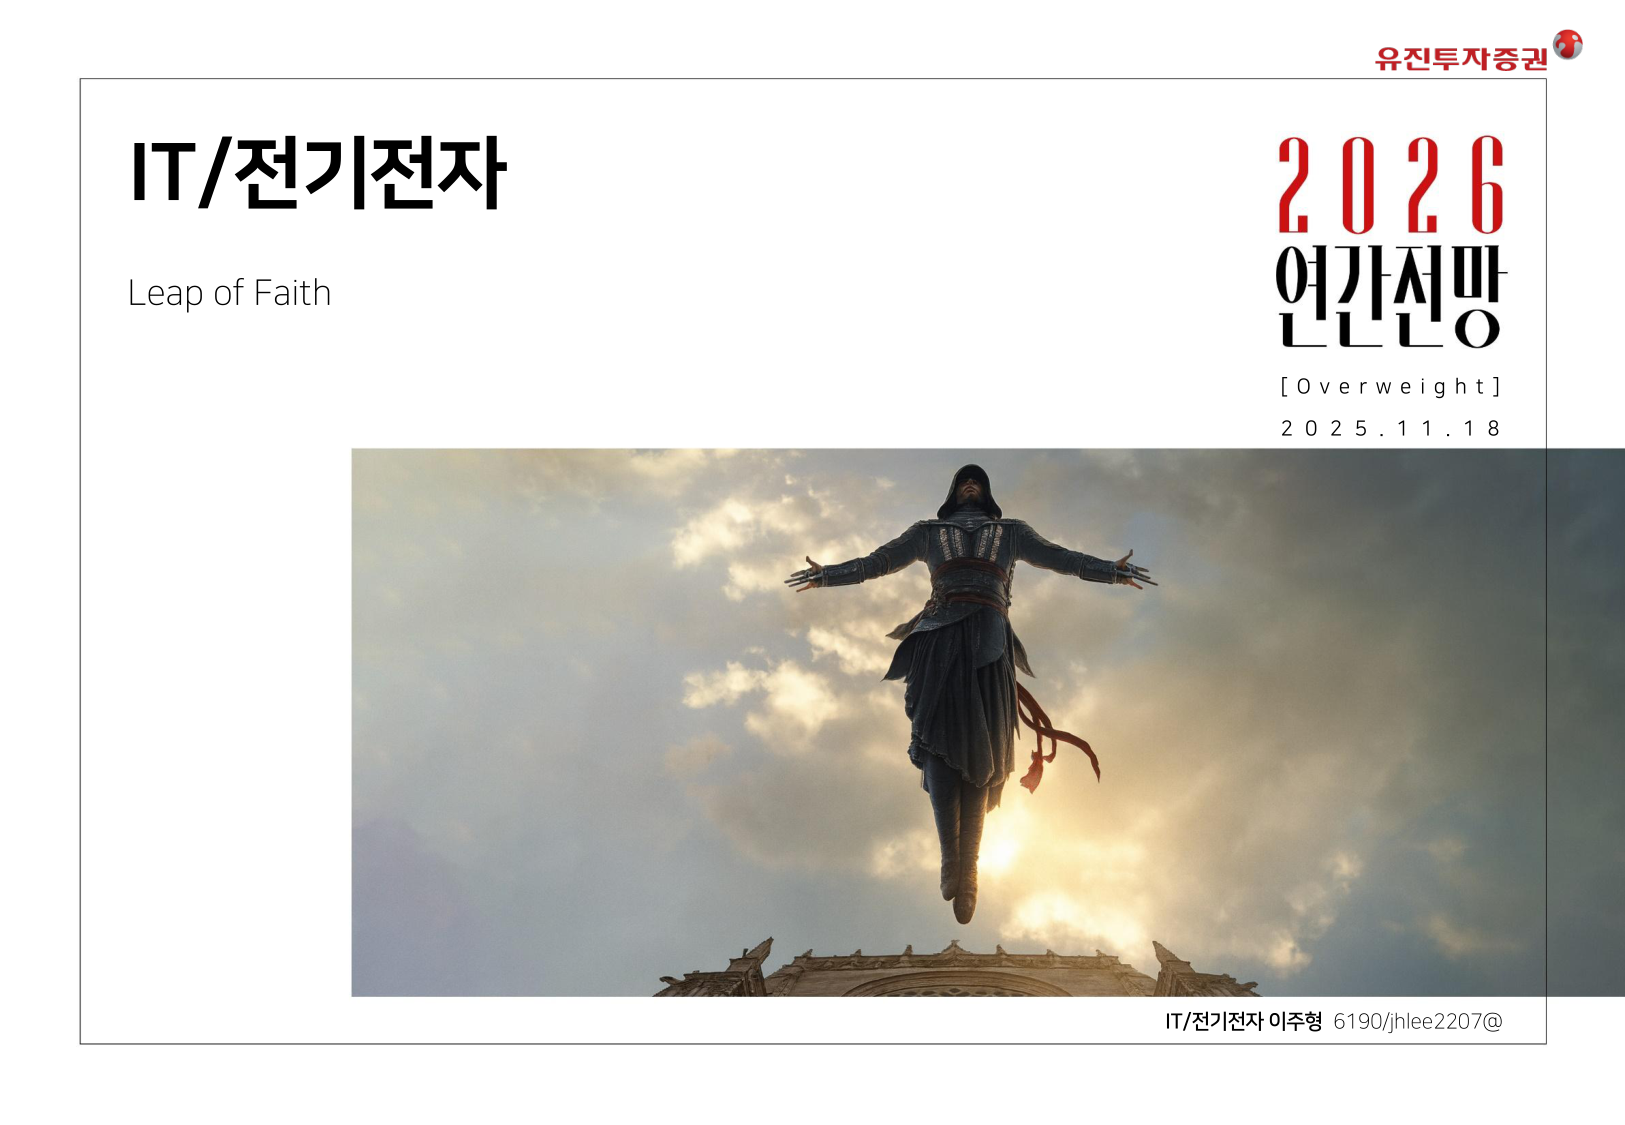

In [61]:
# Step 2: 첫 번째 페이지 이미지 미리보기
from IPython.display import Image, display

# 첫 번째 페이지 표시
if page_images:
    first_page_path = IMAGES_DIR / "page_1.png"
    print(f"📄 첫 번째 페이지 미리보기: {first_page_path}")
    display(Image(filename=str(first_page_path), width=600))

### Step 3: Multi-modal LLM으로 파싱 정확도 검증

Vision Language Model을 사용하여 PDF 원본 이미지와 파싱된 테이블 텍스트를 비교합니다.

**검증 프로세스:**
1. PDF 페이지 이미지 (Base64 인코딩)
2. 파싱된 테이블 텍스트 (HTML 또는 직렬화 결과)
3. Vision LLM이 두 가지를 비교
4. 신뢰도 점수 및 오류 목록 반환

In [62]:
# Step 3: 테이블 파싱 정확도 검증 (O/X 판정)
# 테이블의 직렬화 결과와 해당 페이지 이미지를 비교

if valid_tables and page_images:
    # 검증할 테이블 선택
    table_to_verify = valid_tables[0]
    table_text = serialize_pandas_string(
        table_to_verify["dataframe"], test_metadata
    ).serialized_text

    # 테이블이 있는 페이지 선택 (5번째 이후 페이지에 테이블이 많음)
    page_idx = min(5, len(page_images) - 1)
    page_num, _, page_base64 = page_images[page_idx]

    print("🔍 검증 중...")
    print(f"   - 테이블: {table_to_verify['table_id']}")
    print(f"   - 페이지: {page_num}")
    print(f"   - 파싱된 텍스트 길이: {len(table_text)} 문자\n")

    # Vision LLM으로 검증 실행
    verification_result = verify_table_with_vision_sync(
        page_image_base64=page_base64,
        parsed_table=table_text,
        llm=vision_llm,
    )

    # O/X 결과 출력
    status = verification_result.status_symbol
    print(f"{'=' * 50}")
    print(f"📊 검증 결과: {status}")
    print(f"{'=' * 50}")

    if verification_result.is_pass:
        print("✅ 파싱이 정확합니다. 다음 단계로 진행해도 됩니다.")
    else:
        print("❌ 파싱에 문제가 있습니다. 재작업이 필요합니다!")

        if verification_result.errors:
            print(f"\n⚠️ 발견된 오류 ({len(verification_result.errors)}개):")
            for err in verification_result.errors[:5]:
                print(
                    f"   - [{err.get('type', 'unknown')}] {err.get('description', err)}"
                )
                if err.get("location"):
                    print(f"     위치: {err.get('location')}")

        if verification_result.correction_suggestions:
            print("\n💡 수정 방법:")
            for i, suggestion in enumerate(
                verification_result.correction_suggestions[:3], 1
            ):
                print(f"   {i}. {suggestion}")

        print("\n🔄 위 오류를 수정한 후 다시 검증하세요.")
else:
    print("⚠️ 검증할 테이블이나 이미지가 없습니다.")
    print("   Part B와 Step 1을 먼저 실행하세요.")

🔍 검증 중...
   - 테이블: table_0
   - 페이지: 6
   - 파싱된 텍스트 길이: 282 문자

📊 검증 결과: X
❌ 파싱에 문제가 있습니다. 재작업이 필요합니다!

⚠️ 발견된 오류 (4개):
   - [content] Parsed table output does not match the actual tables in the image. The image contains two line charts with stock price trends, not a tabular data set as shown in the parsed output.
     위치: Entire table
   - [structure] The parsed output presents a table with columns and rows, but the image contains only line charts and legends, not a structured table.
     위치: Entire table
   - [content] Company names and data points in the parsed output do not match the actual chart legends and data in the image. For example, '두산 YTD 100 103 109 121 265 410' does not correspond to any table or explicit data in the image.
     위치: Company rows and data columns
   - [content] Parsed output includes a header 'SK증권 2026년 IT장비/소재 전망' and company/year/unit information that do not appear in the image.
     위치: Table header

💡 수정 방법:
   1. Do not fabricate tabular data from 

### Step 4: 자동 재작업 (Rework)

검증 결과가 X(실패)인 경우, Vision LLM을 사용하여 **자동으로 테이블을 다시 추출**합니다.

**재작업 파이프라인:**
```
검증 X → 오류 정보 수집 → Vision LLM이 이미지에서 직접 추출 → 재검증 → O가 될 때까지 반복
```

**핵심 기능:**
- `verify_and_rework_table_sync()`: 검증 + 재작업 통합 함수
- 최대 3회까지 자동 재시도
- 차트도 데이터 포인트로 추출 가능

In [ ]:
# Step 4: 자동 재작업 (검증 실패 시 LLM이 이미지에서 직접 테이블 추출)
from tabular_utils import verify_and_rework_table_sync, ReworkResult

# 검증 결과가 X인 경우에만 재작업 수행
if "verification_result" in dir() and verification_result.needs_rework:
    print("🔄 자동 재작업 시작...")
    print(f"   - 이전 검증 결과: {verification_result.status_symbol}")
    print(f"   - 오류 수: {len(verification_result.errors)}개\n")

    # 검증 + 재작업 통합 실행 (최대 3회 시도)
    rework_result = verify_and_rework_table_sync(
        page_image_base64=page_base64,
        initial_table=table_text,
        llm=vision_llm,
        max_attempts=3,
    )

    # 결과 출력
    print("=" * 50)
    print(f"📊 재작업 결과: {rework_result.status_symbol}")
    print("=" * 50)
    print(f"   - 시도 횟수: {rework_result.attempt_count}")
    print(f"   - 성공 여부: {'✅ 성공' if rework_result.success else '❌ 실패'}")

    if rework_result.success and rework_result.corrected_df is not None:
        print("📋 수정된 테이블:")
        print(
            f"   크기: {len(rework_result.corrected_df)} 행 x {len(rework_result.corrected_df.columns)} 열"
        )
        display(rework_result.corrected_df.head(10))

        # 메타데이터 출력
        if rework_result.corrected_metadata:
            print("\n📝 추출된 메타데이터:")
            for key, value in rework_result.corrected_metadata.items():
                print(f"   - {key}: {value}")
    else:
        print("\n⚠️ 재작업이 완전히 성공하지 못했습니다.")
        if rework_result.final_verification:
            print(
                f"   마지막 검증 결과: {rework_result.final_verification.status_symbol}"
            )
            if rework_result.final_verification.errors:
                print("   남은 오류:")
                for err in rework_result.final_verification.errors[:3]:
                    print(f"     - {err.get('description', str(err))[:60]}...")
else:
    print("✅ 검증이 이미 통과했거나, 검증 결과가 없습니다.")
    print("   재작업이 필요하지 않습니다.")

🔄 자동 재작업 시작...
   - 이전 검증 결과: X
   - 오류 수: 4개

📊 재작업 결과: O
   - 시도 횟수: 2
   - 성공 여부: ✅ 성공

📋 수정된 테이블:
   크기: 2 행 x 2 열


,chart,companies
0,전기전자 대형주 주가 추이,"[{'name': '두산', 'YTD': '+255%'}, {'name': '삼성전..."
1,전기전자 중형주 주가 추이,"[{'name': '심텍', 'YTD': '+352%'}, {'name': '티엘비..."



📝 추출된 메타데이터:
   - content_type: chart
   - chart_type: line
   - legend_items: ['두산', '삼성전기', 'LG이노텍', 'LG전자', '심텍', '대덕전자', '코리아써키트', '티엘비', '해성디에스']


In [64]:
# Step 5: 수정된 테이블 저장 (재작업 성공 시)
CORRECTED_DIR = Path("data/tables/corrected")
CORRECTED_DIR.mkdir(parents=True, exist_ok=True)

if (
    "rework_result" in dir()
    and rework_result.success
    and rework_result.corrected_df is not None
):
    # 수정된 테이블을 CSV로 저장
    table_id = rework_result.corrected_metadata.get("table_id", "corrected_table")
    output_path = CORRECTED_DIR / f"{table_id}.csv"

    rework_result.corrected_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print("💾 수정된 테이블 저장 완료")
    print(f"   - 파일: {output_path}")
    print(f"   - 행 수: {len(rework_result.corrected_df)}")
    print(f"   - 컬럼: {list(rework_result.corrected_df.columns)}")

    # 메타데이터도 JSON으로 저장
    import json

    meta_path = CORRECTED_DIR / f"{table_id}_metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(rework_result.corrected_metadata, f, ensure_ascii=False, indent=2)
    print(f"   - 메타데이터: {meta_path}")

    print("\n✅ 완전한 테이블 데이터가 준비되었습니다!")
else:
    print("⚠️ 저장할 수정된 테이블이 없습니다.")
    print("   Step 4에서 재작업이 성공해야 저장됩니다.")

💾 수정된 테이블 저장 완료
   - 파일: data/tables/corrected/corrected_table.csv
   - 행 수: 2
   - 컬럼: ['chart', 'companies']
   - 메타데이터: data/tables/corrected/corrected_table_metadata.json

✅ 완전한 테이블 데이터가 준비되었습니다!


---

## 강의 시점 기준: 최근의 접근 방식

> **중요**: 위의 직렬화 방법들은 기본적인 접근입니다. 
> 강의시점 기준 현재의 LLM의 발전된 능력을 최대한 활용하려면 다음 기법들을 사용하면 좋습니다.

### 연구 기반 권장 사항

[Microsoft Research SUC 벤치마크](https://www.microsoft.com/en-us/research/blog/improving-llm-understanding-of-structured-data-and-exploring-advanced-prompting-methods/)에 따르면:

| 포맷 | LLM 정확도 | 권장 여부 |
|------|-----------|----------|
| **XML** | ★★★ 최고 | ✅ 2025년 권장 |
| Markdown | ★★☆ 양호 | ⭕ 대안 |
| JSON | ★★☆ 양호 | ⭕ API용 |
| CSV/TSV | ★☆☆ 낮음 | ❌ 비권장 |

**핵심 발견:**
- XML이 CSV보다 **6.76% 높은 정확도**
- Few-shot learning과 조합 시 일관된 성능 개선
- Self-Augmented Prompting으로 중간 구조적 통찰력 생성

---

### 이 섹션에서 다루는 내용
1. **XML 직렬화** - LLM이 가장 잘 이해하는 형식
2. **프롬프팅 전략** - Few-shot, Self-Augmented
3. **Structured Output** - JSON Schema 기반 추출
4. **이미지 직접 전달** - 멀티모달 테이블 처리

In [ ]:
from tabular_utils import (
    serialize_html,
    create_fewshot_prompt,
    create_self_augmented_prompt,
    compare_serialization_methods_v2,
    extract_table_structured_sync,
    extracted_to_dataframe,
    ExtractedTableData,
)

print("   - serialize_html: XML 직렬화 (권장)")
print("   - create_fewshot_prompt: Few-shot 프롬프팅")
print("   - create_self_augmented_prompt: Self-Augmented 프롬프팅")
print("   - extract_table_structured_sync: Structured Output 추출")

   - serialize_html: HTML 직렬화 (권장)
   - create_fewshot_prompt: Few-shot 프롬프팅
   - create_self_augmented_prompt: Self-Augmented 프롬프팅
   - extract_table_structured_sync: Structured Output 추출


### Step 1: XML 직렬화 vs 기존 방법 비교

Microsoft Research에 따르면 XML 형식이 CSV/TSV보다 6.76% 높은 정확도를 보입니다.  
이는 XML의 명시적 구조(`<table>`, `<tr>`, `<th>`, `<td>`)가 LLM의 테이블 구조 이해를 돕기 때문입니다.

In [66]:
# HTML 직렬화 결과 확인
html_result = serialize_html(df, test_metadata)

print("📊 HTML 직렬화 결과 (2025년 권장)\n")
print(html_result.serialized_text)
print(f"\n토큰 수: {html_result.token_estimate}")

📊 HTML 직렬화 결과 (2025년 권장)

<!-- Table Metadata -->
<!-- title: SK증권 2026년 IT장비/소재 전망 -->
<!-- company: SK증권 -->
<!-- unit: 억원 -->
<!-- year: 2026 -->

<table border="1" class="dataframe data-table">
  <thead>
    <tr style="text-align: right;">
      <th>Year</th>
      <th>Quarter</th>
      <th>Revenue</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>2025</td>
      <td>Q1</td>
      <td>380.2</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q2</td>
      <td>392.4</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q3</td>
      <td>405.7</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q4</td>
      <td>418.9</td>
    </tr>
  </tbody>
</table>

토큰 수: 265


In [ ]:
# 직렬화 방법 비교 (XML 포함)
comparison_v2 = compare_serialization_methods_v2(df, test_metadata)

print("직렬화 방법 비교 (2025년 버전)")
print("   (GPT-4.1: 1M 토큰, Claude: 200K 토큰 지원)")
display(comparison_v2)

직렬화 방법 비교 (2025년 버전)
   (GPT-4.1: 1M 토큰, Claude: 200K 토큰 지원)


,method,tokens,chars,tokens_per_row,llm_accuracy,recommendation
3,compressed_json,97,178,24.25,★★☆,
0,pandas_string,105,167,26.25,★★☆,
1,narrative,124,222,31.00,★★☆,
2,schema_summary,167,260,41.75,★★☆,
5,query_adaptive,167,260,41.75,★★☆,
4,selective_stats,171,282,42.75,★★☆,
6,html (권장),265,646,66.25,★★★,2025 권장


### Step 2: 프롬프팅 전략

단순히 테이블을 직렬화하는 것보다, **프롬프팅 전략**을 함께 사용하면 LLM의 이해도가 크게 향상됩니다.

| 전략 | 설명 | 효과 |
|------|------|------|
| **Few-shot** | 예시 QA 쌍 제공 | 답변 형식 학습 |
| **Self-Augmented** | 스키마/패턴 분석 선행 | 구조적 통찰력 향상 |
| **Chain-of-Thought** | 단계별 추론 유도 | 복잡한 계산 정확도 ↑ |

In [68]:
# Few-shot 프롬프팅 예시
fewshot_examples = [
    {
        "question": "Q2 매출은 얼마인가요?",
        "answer": "2025년 Q2 매출은 392.4 백만 달러입니다.",
    },
    {
        "question": "매출이 가장 높은 분기는?",
        "answer": "Q4가 418.9 백만 달러로 가장 높습니다.",
    },
]

fewshot_prompt = create_fewshot_prompt(
    df,
    test_metadata,
    examples=fewshot_examples,
    serialization_method="html",  # HTML 사용
)

print("📝 Few-shot 프롬프팅 (HTML + 예시 QA)\n")
print(fewshot_prompt[:1500])
print("..." if len(fewshot_prompt) > 1500 else "")

📝 Few-shot 프롬프팅 (HTML + 예시 QA)

## 테이블 정보
- 제목: SK증권 2026년 IT장비/소재 전망
- 회사: SK증권
- 단위: 억원
- 행 수: 4

## 테이블 데이터
<!-- Table Metadata -->
<!-- title: SK증권 2026년 IT장비/소재 전망 -->
<!-- company: SK증권 -->
<!-- unit: 억원 -->
<!-- year: 2026 -->

<table border="1" class="dataframe data-table">
  <thead>
    <tr style="text-align: right;">
      <th>Year</th>
      <th>Quarter</th>
      <th>Revenue</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>2025</td>
      <td>Q1</td>
      <td>380.2</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q2</td>
      <td>392.4</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q3</td>
      <td>405.7</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q4</td>
      <td>418.9</td>
    </tr>
  </tbody>
</table>

## 예시 QA
Q1: Q2 매출은 얼마인가요?
A1: 2025년 Q2 매출은 392.4 백만 달러입니다.

Q2: 매출이 가장 높은 분기는?
A2: Q4가 418.9 백만 달러로 가장 높습니다.




In [ ]:
# Self-Augmented 프롬프팅 (구조적 통찰력 포함)
self_aug_prompt = create_self_augmented_prompt(df, test_metadata)

print("🧠 Self-Augmented 프롬프팅 (스키마 분석 + 패턴 식별)\n")
print(self_aug_prompt)

print("\n" + "=" * 50)
print("💡 Self-Augmented 프롬프팅의 장점:")
print("   1. 스키마 분석이 선행되어 LLM이 컬럼 의미를 이해")
print("   2. 패턴 식별로 추세/변화율 계산이 정확해짐")
print("   3. XML 형식으로 구조 이해도 최대화")

🧠 Self-Augmented 프롬프팅 (스키마 분석 + 패턴 식별)

## 1단계: 테이블 메타데이터 이해
- 제목: SK증권 2026년 IT장비/소재 전망
- 출처: SK증권
- 단위: 억원
- 연도: 2026

## 2단계: 스키마 분석 (컬럼별 특성)
- Year (int64): 숫자형, 범위 [2025.00 ~ 2025.00], 평균 2025.00
- Quarter (object): 문자형, 4개 고유값, 예시: ['Q1', 'Q2', 'Q3']
- Revenue (float64): 숫자형, 범위 [380.20 ~ 418.90], 평균 399.30

## 3단계: 핵심 패턴 식별
- Year: 유지 추세 (+0.0%)
- Revenue: 상승 추세 (+10.2%)

## 4단계: 테이블 데이터 (HTML 형식 - 최고 성능)
<!-- Table Metadata -->
<!-- title: SK증권 2026년 IT장비/소재 전망 -->
<!-- company: SK증권 -->
<!-- unit: 억원 -->
<!-- year: 2026 -->

<table border="1" class="dataframe data-table">
  <thead>
    <tr style="text-align: right;">
      <th>Year</th>
      <th>Quarter</th>
      <th>Revenue</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>2025</td>
      <td>Q1</td>
      <td>380.2</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q2</td>
      <td>392.4</td>
    </tr>
    <tr>
      <td>2025</td>
      <td>Q3</td>
      <td>405.7</td>
    </tr>
    <tr>
      <td>2025</td>
      

### Step 3: Structured Output (JSON Schema 기반 추출)

LLM 출력을 **JSON Schema로 강제**하면:
- 파싱 오류 감소
- 일관된 데이터 구조
- 신뢰도(confidence) 점수 포함

```json
{
    "headers": ["Year", "Quarter", "Revenue"],
    "rows": [["2025", "Q1", "380.2"], ...],
    "metadata": {"title": "...", "unit": "..."},
    "confidence": 0.95
}
```

In [ ]:
# Structured Output으로 이미지에서 테이블 추출
# NOTE: 실패할 가능성이 매우 높음! LLM 에 의존하는 데이터 추출방식 이기 때문입니다.
if page_images:
    # 테이블이 있는 페이지 선택
    test_page_idx = min(10, len(page_images) - 1)  # 테이블이 많은 페이지
    _, _, test_image_base64 = page_images[test_page_idx]

    print("🔍 Structured Output으로 테이블 추출 중...")
    print(f"   - 페이지: {test_page_idx + 1}")

    # JSON Schema 기반 추출
    extracted = extract_table_structured_sync(
        image_base64=test_image_base64,
        llm=vision_llm,
    )

    print("\n📊 추출 결과:")
    print(f"   - 신뢰도: {extracted.confidence:.0%}")
    print(
        f"   - 헤더: {extracted.headers[:5]}..."
        if len(extracted.headers) > 5
        else f"   - 헤더: {extracted.headers}"
    )
    print(f"   - 행 수: {len(extracted.rows)}")

    # DataFrame으로 변환
    extracted_df = extracted_to_dataframe(extracted)
    if extracted_df is not None:
        print("\n📋 추출된 테이블 미리보기:")
        display(extracted_df.head())

    # 메타데이터 출력
    if extracted.metadata:
        print("\n📝 추출된 메타데이터:")
        for k, v in extracted.metadata.items():
            print(f"   - {k}: {v}")
else:
    print("⚠️ 이미지가 없습니다. Part D를 먼저 실행하세요.")

🔍 Structured Output으로 테이블 추출 중...
   - 페이지: 11

📊 추출 결과:
   - 신뢰도: 0%
   - 헤더: []
   - 행 수: 0


| 기법 | 적용 시점 | 효과 |
|------|----------|------|
| **HTML 직렬화** | 항상 | LLM 정확도 +6.76% |
| **Few-shot** | QA 형식이 중요할 때 | 답변 형식 일관성 |
| **Self-Augmented** | 복잡한 분석 시 | 구조적 통찰력 향상 |
| **Structured Output** | 자동화 파이프라인 | 파싱 오류 제거 |

**권장 파이프라인:**
```
PDF → 이미지 변환 → `Document Parsing` → XML 직렬화 → Self-Augmented 프롬프팅 → LLM
```

---

## 토큰 효율성 최적화

> **중요**: XML은 LLM 정확도가 높지만 토큰을 많이 소비합니다.  
> 비용이나 컨텍스트 길이가 중요한 경우, **TOON**과 **PLOON** 같은 토큰 최적화 포맷을 고려하세요.

### 왜 토큰 효율성이 중요한가?

| 시나리오 | XML 문제점 | 해결책 |
|----------|------------|--------|
| 대형 테이블 (1000+ 행) | 컨텍스트 한계 초과 | PLOON (49% 절감) |
| 대량 API 호출 | 비용 증가 | TOON/PLOON |
| 실시간 시스템 | 레이턴시 증가 | 압축 포맷 |
| 다중 테이블 처리 | 컨텍스트 경쟁 | 선택적 직렬화 |

### TOON vs PLOON

| 포맷 | 절감률 (vs JSON) | 특징 | LLM 정확도 |
|------|-----------------|------|----------|
| **TOON** | ~40% | YAML + CSV 조합, 읽기 쉬움 | ★★★ |
| **PLOON** | ~49% | 경로 기반, 최대 압축 | ★★★ |
| **PLOON Minified** | ~55% | 줄바꿈 제거 | ★★☆ |

**참고 자료:**
- [TOON Format](https://github.com/toon-format/toon) - Token-Oriented Object Notation
- [PLOON Format](https://github.com/ulpi-io/ploon-js) - Path-Level Object Oriented Notation

In [72]:
# 토큰 효율성 최적화 - TOON/PLOON 직렬화
from tabular_utils import (
    serialize_toon,
    serialize_toon_compact,
    serialize_ploon,
    serialize_ploon_minified,
    serialize_html_compact,
    compare_all_serialization_methods,
)

print("   - serialize_toon: TOON 형식 (JSON 대비 40% 절감)")
print("   - serialize_ploon: PLOON 형식 (JSON 대비 49% 절감)")
print("   - serialize_html_compact: HTML 압축 (정확도 유지)")
print("   - compare_all_serialization_methods: 직렬화 방법 비교")

   - serialize_toon: TOON 형식 (JSON 대비 40% 절감)
   - serialize_ploon: PLOON 형식 (JSON 대비 49% 절감)
   - serialize_html_compact: HTML 압축 (정확도 유지)
   - compare_all_serialization_methods: 직렬화 방법 비교


### Step 1: TOON 형식 살펴보기

TOON (Token-Oriented Object Notation)은 YAML-like 인덴트와 CSV-style 테이블을 조합합니다.
읽기 쉬우면서도 JSON 대비 **40% 토큰 절감**을 달성합니다.

In [73]:
# TOON 형식 예시
toon_result = serialize_toon(df, test_metadata)

print("📊 TOON 형식 출력\n")
print(toon_result.serialized_text)
print(f"\n{'=' * 40}")
print(f"토큰 수: {toon_result.token_estimate}")
print(f"HTML 대비: {html_result.token_estimate - toon_result.token_estimate} 토큰 절감")

📊 TOON 형식 출력

meta:
  title: SK증권 2026년 IT장비/소재 전망
  company: SK증권
  unit: 억원
  year: 2026
data[4]{Year,Quarter,Revenue}:
  2025,Q1,380.2
  2025,Q2,392.4
  2025,Q3,405.7
  2025,Q4,418.9

토큰 수: 104
HTML 대비: 161 토큰 절감


### Step 2: PLOON 형식 살펴보기

PLOON (Path-Level Object Oriented Notation)은 경로 기반 계층 구조로 **최대 압축**을 달성합니다.
TOON보다 14% 더 효율적이며, Minified 모드에서는 줄바꿈까지 제거합니다.

In [74]:
# PLOON 형식 예시 (Standard vs Minified)
ploon_result = serialize_ploon(df, test_metadata)
ploon_min_result = serialize_ploon_minified(df, test_metadata)

print("📊 PLOON 형식 (Standard)\n")
print(ploon_result.serialized_text)
print(f"\n토큰 수: {ploon_result.token_estimate}")

print(f"\n{'=' * 50}")
print("\n📊 PLOON 형식 (Minified - 최소 토큰)\n")
print(ploon_min_result.serialized_text)
print(f"\n토큰 수: {ploon_min_result.token_estimate}")

print(f"\n{'=' * 50}")
print("💡 비교:")
print(f"   HTML:           {html_result.token_estimate} 토큰")
print(f"   TOON:           {toon_result.token_estimate} 토큰")
print(f"   PLOON:          {ploon_result.token_estimate} 토큰")
print(f"   PLOON Minified: {ploon_min_result.token_estimate} 토큰")

📊 PLOON 형식 (Standard)

[meta](t:SK증권 2026년 IT장비/소재 전망,c:SK증권,u:억원,y:2026)
[data#4](Year,Quarter,Revenue)
1:0|2025|Q1|380.2
1:1|2025|Q2|392.4
1:2|2025|Q3|405.7
1:3|2025|Q4|418.9

토큰 수: 108


📊 PLOON 형식 (Minified - 최소 토큰)

[meta](t:SK증권 2026년 IT장비/소재 전망,c:SK증권,u:억원,y:2026);[data#4](Year,Quarter,Revenue);1:0|2025|Q1|380.2;1:1|2025|Q2|392.4;1:2|2025|Q3|405.7;1:3|2025|Q4|418.9

토큰 수: 109

💡 비교:
   HTML:           265 토큰
   TOON:           104 토큰
   PLOON:          108 토큰
   PLOON Minified: 109 토큰


### Step 3: 모든 직렬화 방법 전체 비교

In [ ]:
full_comparison = compare_all_serialization_methods(df, test_metadata)

display(full_comparison)

print("\n" + "=" * 60)
print("💡 권장 사항:")
print("   ✅ 정확도 우선: XML 또는 XML Compact")
print("   ✅ 토큰 효율 우선: PLOON Minified 또는 TOON")
print("   ✅ 균형점: TOON (읽기 쉬우면서 효율적)")

,method,tokens,chars,savings_%,accuracy,use_case
3,compressed_json,97,178,7.6%,★★☆,API 통신
9,toon_compact,103,151,1.9%,★★★,TOON 압축
8,toon,104,171,1.0%,★★★,40% 절감
0,pandas_string,105,167,-,★★☆,기본
10,ploon,108,153,-2.9%,★★★,49% 절감
11,ploon_minified,109,153,-3.8%,★★★,최대 절감
1,narrative,124,222,-18.1%,★★☆,자연어 QA
2,schema_summary,167,260,-59.0%,★★☆,대형 테이블
5,query_adaptive,167,260,-59.0%,★★☆,검색 기반
7,html_compact,168,299,-60.0%,★★★,정확도+효율



💡 권장 사항:
   ✅ 정확도 우선: HTML 또는 HTML Compact
   ✅ 토큰 효율 우선: PLOON Minified 또는 TOON
   ✅ 균형점: TOON (읽기 쉬우면서 효율적)


### 토큰 효율성 최적화 측면

| 상황 | 권장 포맷 | 이유 |
|------|----------|------|
| **일반적 사용** | HTML | 최고 정확도 (6.76%↑) |
| **대형 테이블 (100+ 행)** | PLOON | 49% 토큰 절감 |
| **대량 API 호출** | TOON/PLOON | 비용 절감 |
| **컨텍스트 길이 제한** | PLOON Minified | 최대 압축 |
| **읽기 쉬움 필요** | TOON | YAML-like 구조 |
| **정확도 + 효율** | HTML Compact | 균형점 |

---

## 핵심 학습 내용

1. **테이블 데이터의 암묵적 정보**
   - 테이블만으로는 회사, 연도, 단위, 통화 등 중요한 컨텍스트가 누락됨
   - LLM이 올바르게 해석하려면 **명시적 메타데이터 주입**이 필수

2. **직렬화 방법**
   | 방법 | 토큰 효율 | LLM 정확도 | 권장 사용 |
   |------|----------|-----------|----------|
   | Pandas String | 중간 | ★★☆ | 기본 |
   | Narrative | 낮음 | ★★☆ | 자연어 QA |
   | Schema+Summary | 높음 | ★★☆ | 도구 사용 시 |
   | Compressed JSON | 높음 | ★★☆ | API 통신 |
   | Selective Stats | 높음 | ★★☆ | 대형 테이블 |
   | Query-Adaptive | 높음 | ★★☆ | 검색 기반 |
   | **XML** | 중간 | **★★★** | **기본** |
   | XML Compact | 높음 | ★★★ | 정확도+효율 |
   | **TOON** | **높음** | ★★★ | **40% 절감** |
   | TOON Compact | 최고 | ★★★ | TOON 압축 |
   | **PLOON** | **최고** | ★★★ | **49% 절감** |
   | PLOON Minified | 최고 | ★★☆ | 최대 압축 |

3. **Multi-modal 검증 + 자동 재작업**
   - Vision LLM으로 파싱 정확도 자동 검증 (O/X 판정)
   - 검증 실패 시 자동 재작업 → 이미지에서 직접 테이블 추출
   - 최대 3회 재시도로 완전한 데이터 확보

4. **Table 표현 방식 + LLM 활용을 통한 Contextual Tabular Data 를 만드는 방법**
   - **XML 직렬화**: CSV보다 6.76% 높은 LLM 정확도
   - **프롬프팅 전략**: Few-shot, Self-Augmented
   - **Structured Output**: JSON Schema 기반 추출

5. **토큰 효율성 최적화**
   - **TOON**: JSON 대비 40% 토큰 절감, 읽기 쉬움
   - **PLOON**: JSON 대비 49% 토큰 절감, 최대 압축
   - 대형 테이블/대량 API 호출 시 비용 절감에 효과적

### 권장 파이프라인
```
PDF → 이미지 변환 → Structured Output 추출 
    → XML 직렬화 (또는 TOON/PLOON) → Self-Augmented 프롬프팅 → LLM
    
(검증 실패 시)
    → Vision LLM 자동 재작업 → 완전한 데이터

(토큰 제한 시)
    → PLOON Minified 또는 TOON Compact 사용
```

### 참고 자료
- [Microsoft Research: Improving LLM understanding of structured data](https://www.microsoft.com/en-us/research/blog/improving-llm-understanding-of-structured-data-and-exploring-advanced-prompting-methods/)
- [Table Meets LLM Benchmark (arXiv)](https://arxiv.org/abs/2305.13062)
- [Awesome-Tabular-LLMs (GitHub)](https://github.com/SpursGoZmy/Awesome-Tabular-LLMs)
- [TOON Format (GitHub)](https://github.com/toon-format/toon) - Token-Oriented Object Notation
- [PLOON Format (GitHub)](https://github.com/ulpi-io/ploon-js) - Path-Level Object Oriented Notation